# Previsão de Churn: Análise Estratégica para Retenção de Clientes

## SUMÁRIO

[1. INTRODUÇÃO E CONTEXTUALIZAÇÃO 🚀](#1-introducao) <br>
[2. OBJETIVOS DO PROJETO 🎯](#2-objetivos) <br>
[3. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES INICIAIS 📚](#3-importação-de-bibliotecas) <br>
[4. CARREGAMENTO E PRÉ-PROCESSAMENTO DOS DADOS 🔄](#4-carregamento-dos-dados) <br>
[5. ANÁLISE EXPLORATÓRIA DE DADOS (EDA) 📊](#5-analise-exploratoria) <br>
[6. TRATAMENTO, LIMPEZA E DIVISÃO DO CONJUNTO DE DADOS 🔧](#6-tratamento-de-dados) <br>
[7. ENGENHARIA DE FEATURES ⚙️](#7-feature-engineering) <br>
[8. DIVISÃO DO CONJUNTO DE DADOS, BALANCEAMENTO E ESCALONAMENTO 🔀](#8-balanceamento-escalonamento) <br>
[9. MODELAGEM E VALIDAÇÃO 🤖](#9-modelagem) <br>
[10. AVALIAÇÃO FINAL E VEREDITO DE NEGÓCIOS 📏](#10-avaliacao-final)

## 1. Introdução e Contextualização 🚀 <a id='1-introducao'></a>

No dinâmico mercado de varejo digital (E-commerce), a retenção de clientes tornou-se tão ou mais importante do que a aquisição de novos. O custo de aquisição de um novo cliente (CAC) é comprovadamente superior ao custo de manutenção de um cliente ativo na plataforma. Nesse cenário, o fenômeno do *Churn* — que representa o abandono da plataforma pelo usuário — gera impactos negativos diretos no faturamento e no valor de tempo de vida do cliente (*Customer Lifetime Value* - LTV).

Sob a ótica da Ciência de Dados, dados brutos não estruturados ou mal preparados representam um risco severo para as corporações. A inserção de dados inconsistentes, duplicados ou com distribuições enviesadas em algoritmos preditivos resulta no clássico axioma **'Garbage In, Garbage Out' (Lixo Entra, Lixo Sai)**. Modelos construídos sem o devido rigor metodológico tendem a apresentar métricas de desempenho falsamente otimistas na fase de desenvolvimento (overfitting), mas falham de maneira catastrófica ao operar em ambiente de produção com novos clientes. Para um aplicativo de e-commerce, essas falhas traduzem-se em desperdício massivo de recursos com cupons preventivos ineficazes ou na perda definitiva de clientes valiosos, prejudicando a credibilidade institucional.

Este projeto desenvolve um pipeline preditivo de ponta a ponta para identificar padrões de comportamento que precedem o cancelamento de uma conta ou serviço. O trabalho está estruturado em:
1. **EDA Profunda**: Para entender a base de clientes.
2. **Engenharia de Features**: Criação de variáveis para extrair maior valor dos dados.
3. **Modelagem Preditiva**: Comparação entre diferentes modelos para encontrar a melhor performance.
4. **Interpretação de Negócio**: Traduzir métricas de erro em potencial de economia de receita.


## 2. Objetivos do Projeto 🎯 <a id='2-objetivos'></a>

### Objetivo Geral
Construir um pipeline preditivo robusto utilizando algoritmos clássicos de Machine Learning (K-Nearest Neighbors e Árvores de Decisão) para prever a probabilidade de Churn de clientes em uma plataforma de E-commerce, visando subsidiar tomadas de decisões automatizadas de marketing de retenção.

### Objetivos Específicos
* Executar uma Análise Exploratória de Dados (EDA) quantitativa e visual, diagnosticando o comportamento das variáveis explicativas e o desbalanceamento da variável alvo.
* Implementar o tratamento estatístico fundamentado de dados faltantes (nulos), registros duplicados e valores discrepantes (*outliers*), mitigando sensibilidades específicas do KNN.
* Realizar Engenharia de Features de forma segura para criar indicadores de valor.
* Estruturar partições de dados evitando o vazamento de dados (*Data Leakage*) durante o balanceamento por reamostragem (SMOTE) e o escalonamento de variáveis contínuas.
* Otimizar hiperparâmetros para ambos os modelos, monitorando o comportamento de sobreajuste (overfitting).
* Analisar os resultados sob a ótica da Matriz de Confusão e estabelecer um Veredito de Negócio ponderado pelo impacto financeiro dos Falsos Positivos e Falsos Negativos na operação de varejo.
* Priorizar a identificação do maior número possível de potenciais churners (mesmo que isso aumente um pouco os falsos positivos), pois o custo de retenção é menor que o custo de perda do cliente.

## 3. Importação de Bibliotecas e Configurações Iniciais 📚 <a id='3-importação-de-bibliotecas'></a>

Nesta seção, será feito o carregamento das bibliotecas necessárias para análise e modelagem dos dados. O ecossistema Scikit-Learn é usado para modelagem e pré-processamento, a biblioteca Imbalanced-Learn para a manipulação segura de classes desbalanceadas, além de Pandas, NumPy, Matplotlib e Seaborn para manipulação matemática e visualizações gráficas.

In [ ]:
# Importação das bibliotecas do sistema e manipulação de dados
import warnings
import numpy as np
import pandas as pd

# Importação de bibliotecas de visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Importação de módulos do Scikit-Learn para pré-processamento e split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Importação de modelos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Importação de métricas de avaliação e matriz de confusão
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# Importação do ecossistema Imbalanced-Learn para tratamento de classes
from imblearn.over_sampling import SMOTE

# Configurações do ambiente de desenvolvimento
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 4. Carregamento e Pré-Processamento dos Dados 🔄 <a id='4-carregamento-dos-dados'></a>

Nesta fase, a base de dados será carregada e será efetuado o entendimento das colunas que compõem o dataset.


In [2]:
file_path = '..\data\ecommerce_dataset.csv'
df = pd.read_csv(file_path)

# Visualização inicial
display(df.head())

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


### Dicionário de Dados - Churn E-Commerce

Este dicionário de dados descreve as variáveis presentes na base de dados de churn de e-commerce, mantendo os nomes originais das colunas e detalhando suas descrições em português.

| Nome da Coluna | Descrição |
| :--- | :--- |
| **CustomerID** | Identificador exclusivo e único de cada cliente na base de dados. |
| **Churn** | Indicador de rotatividade (*churn*). Assume o valor **1** se o cliente deixou de utilizar o serviço/plataforma recentemente, ou **0** caso tenha permanecido ativo. |
| **Tenure** | Tempo de fidelidade ou relacionamento do cliente com a empresa. |
| **PreferredLoginDevice** | Dispositivo preferencial utilizado pelo cliente para realizar login na plataforma. |
| **CityTier** | Classificação da cidade do cliente com base no seu nível de desenvolvimento, infraestrutura ou população. |
| **WarehouseToHome** | Distância física calculada entre o centro de distribuição (armazém) mais próximo e a residência cadastrada do cliente. |
| **PreferredPaymentMode** | Forma de pagamento preferida ou mais utilizada pelo cliente para realizar suas compras. |
| **Gender** | Gênero biológico do cliente. |
| **HourSpendOnApp** | Quantidade média de horas que o cliente gasta navegando ou utilizando o aplicativo da plataforma. |
| **NumberOfDeviceRegistered**| Quantidade total de dispositivos eletrônicos distintos cadastrados ou associados à conta do cliente. |
| **PreferedOrderCat** | Categoria de produtos mais comprada ou preferida pelo cliente. |
| **SatisfactionScore** | Nota de satisfação atribuída pelo cliente em relação aos serviços da empresa. |
| **MaritalStatus** | Estado civil declarado do cliente. |
| **NumberOfAddress** | Quantidade total de endereços de entrega cadastrados pelo cliente em sua conta. |
| **Complain** | Indicador de reclamação recente. Registra **1** se o cliente realizou alguma reclamação formal, ou **0** caso não tenha feito reclamações. |
| **OrderAmountHikeFromlastYear**| Aumento no valor gasto em compras pelo cliente em comparação com o ano anterior. |
| **CouponUsed** | Quantidade total de cupons de desconto que foram utilizados pelo cliente para efetuar compras. |
| **OrderCount** |Número total de pedidos concluídos pelo cliente. |
| **DaySinceLastOrder** | Número de dias decorridos desde a última compra realizada pelo cliente. |
| **CashbackAmount** | Valor total acumulado de cashback (retorno financeiro) recebido pelo cliente referente às suas compras. |

## 5. Análise Exploratória de Dados (EDA) 📊 <a id='5-analise-exploratoria'></a>

Nesta seção, serão avaliadas as dimensões do dataset, os tipos de dados contidos nas colunas, o comportamento estatístico das variáveis numéricas e serão geradas visualizações-chave sobre desbalanceamento e correlação.

In [3]:
print('=== Dimensões da Base de Dados ===')
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')

=== Dimensões da Base de Dados ===
Linhas: 5630 | Colunas: 20


In [4]:
print('=== Estrutura, Tipos de Variáveis e Contagem de Valores Não-Nulos ===')
df.info()

=== Estrutura, Tipos de Variáveis e Contagem de Valores Não-Nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  Marita

In [5]:
print('=== Sumário Estatístico das Variáveis Numéricas ===')
display(df.describe().T)

=== Sumário Estatístico das Variáveis Numéricas ===


,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.0,0.00,1.0
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.0,16.00,61.0
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.0,3.00,3.0
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.0,20.00,127.0
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.0,3.00,5.0
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.0,4.00,6.0
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.0,4.00,5.0
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.0,6.00,22.0
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.0,1.00,1.0


In [ ]:
print('=== Sumário Estatístico das Variáveis Categóricas ===')
display(df.describe(include=['O', 'object']).T)

=== Sumário Estatístico das Variáveis Categóricas ===


,count,unique,top,freq
PreferredLoginDevice,5630,3,Mobile Phone,2765
PreferredPaymentMode,5630,7,Debit Card,2314
Gender,5630,2,Male,3384
PreferedOrderCat,5630,6,Laptop & Accessory,2050
MaritalStatus,5630,3,Married,2986


### Análise Gráfica

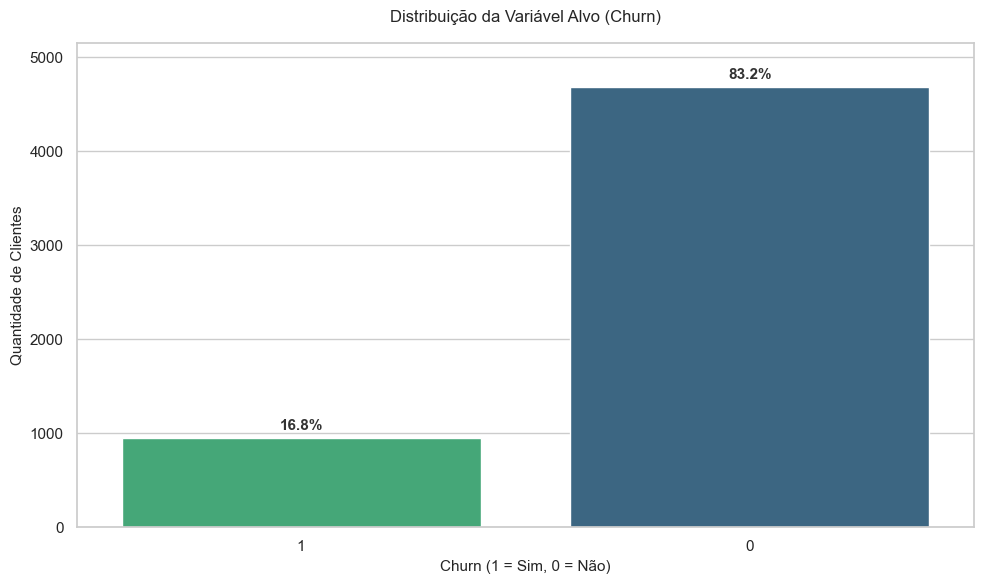

In [7]:
# Criação da coluna Churn_Label do tipo string para uso nas legendas dos gráficos
df['Churn_Label'] = df['Churn'].astype(str)

# FIGURA 1: Distribuição da Variável Alvo (Churn)
ax = sns.countplot(
    data=df, 
    x='Churn_Label', 
    hue='Churn_Label', 
    palette='viridis_r', 
    legend=False
)

# Adicionar os rótulos de porcentagem no topo de cada barra de forma dinâmica
total_customers = len(df)
for p in ax.patches:
    # Calcula a porcentagem de cada barra em relação ao total
    percentage = f'{100 * p.get_height() / total_customers:.1f}%'
    
    # Define as coordenadas para o texto aparecer centralizado acima da barra
    x_coord = p.get_x() + p.get_width() / 2
    y_coord = p.get_height() + (total_customers * 0.01) # Pequeno espaçamento vertical
    
    ax.annotate(
        percentage, 
        (x_coord, y_coord), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='semibold',
        color='#333333'
    )

# Títulos e rótulos idênticos à imagem solicitada
plt.title('Distribuição da Variável Alvo (Churn)', fontsize=12, pad=15)
plt.xlabel('Churn (1 = Sim, 0 = Não)', fontsize=11)
plt.ylabel('Quantidade de Clientes', fontsize=11)

# Ajuste fino das margens para não cortar o texto do topo
plt.ylim(0, df['Churn_Label'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

O gráfico revela um cenário clássico de desbalanceamento de classes, onde a grande maioria dos clientes pertence à classe de clientes retidos e apenas uma pequena fração representa a classe de interesse (churn). Para mitigar esse efeito, será indispensável adotar estratégias de técnicas de amostragem (como SMOTE ou undersampling) e a escolha de métricas de avaliação mais robustas e focadas na classe minoritária, a exemplo do F1-Score e Recall.

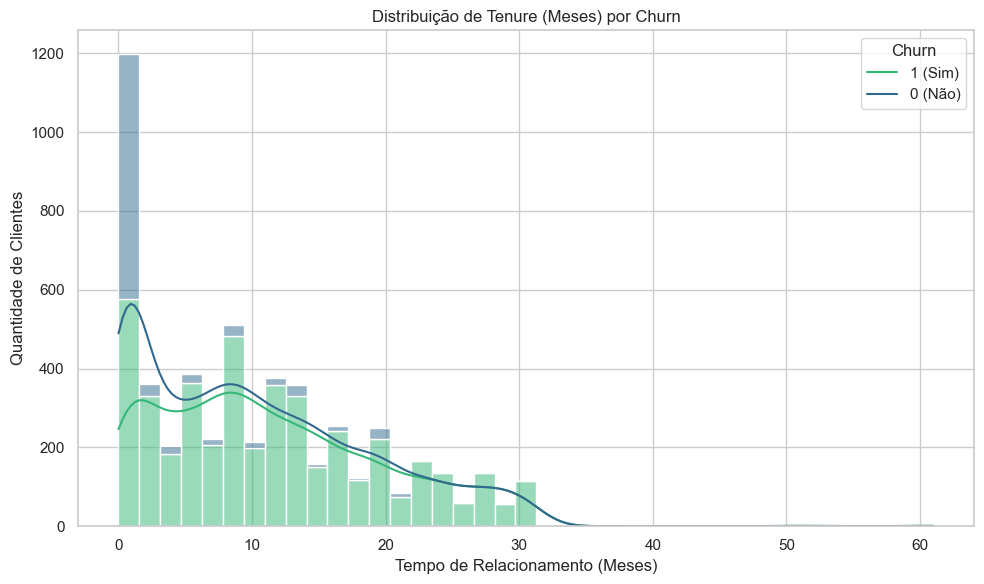

In [8]:
# FIGURA 2: Distribuição de Tenure por Churn
sns.histplot(data=df, x='Tenure', hue='Churn_Label', multiple='stack', kde=True, palette='viridis')
plt.title('Distribuição de Tenure (Meses) por Churn')
plt.xlabel('Tempo de Relacionamento (Meses)')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn', labels=['1 (Sim)', '0 (Não)'])
plt.tight_layout()
plt.show()


O histograma de `Tenure` mostra que a grande maioria dos casos de churn (em verde) ocorre nos primeiros meses de relacionamento do cliente com a plataforma. Conforme o cliente avança no tempo de relacionamento (especialmente após o primeiro ano), a taxa de cancelamento cai consideravelmente. Isso indica que a plataforma enfrenta um problema crítico de retenção inicial e que campanhas de onboarding ou benefícios para novos clientes nos primeiros meses podem ser uma boa estratégia.

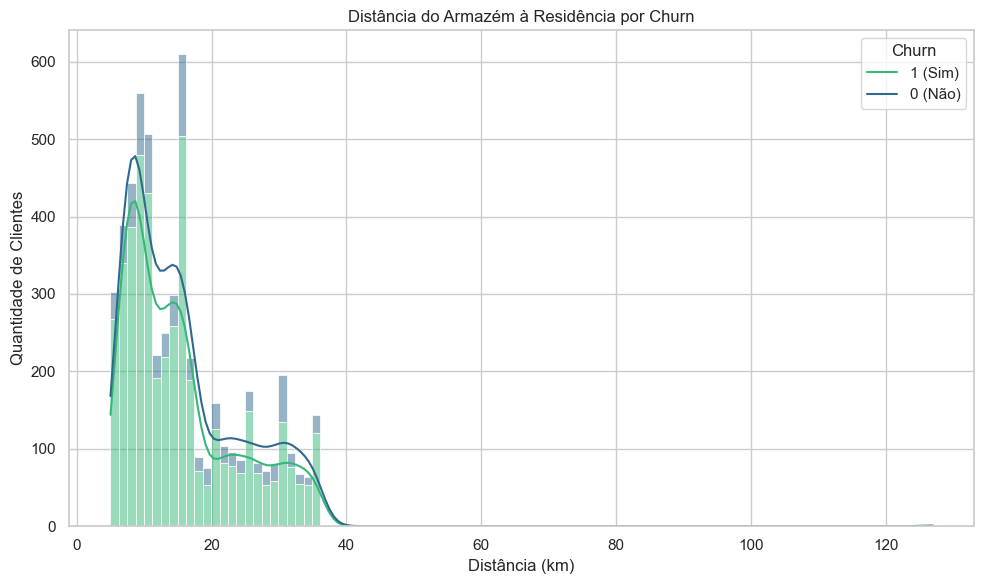

In [9]:
# FIGURA 3: Distância do Armazém à Residência por Churn
sns.histplot(data=df, x='WarehouseToHome', hue='Churn_Label', multiple='stack', kde=True, palette='viridis')
plt.title('Distância do Armazém à Residência por Churn')
plt.xlabel('Distância (km)')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn', labels=['1 (Sim)', '0 (Não)'])
plt.tight_layout()
plt.show()

A distribuição de `WarehouseToHome` (distância do armazém até a casa do cliente) é assimétrica à direita, com maior concentração de clientes morando perto dos centros de distribuição. Nota-se que, proporcionalmente, clientes que moram em distâncias maiores possuem maior probabilidade de churn, o que é um indício de que prazos de entrega mais longos ou custos de frete gerados pela distância física dos armazéns podem ser fatores de insatisfação que levam ao cancelamento.

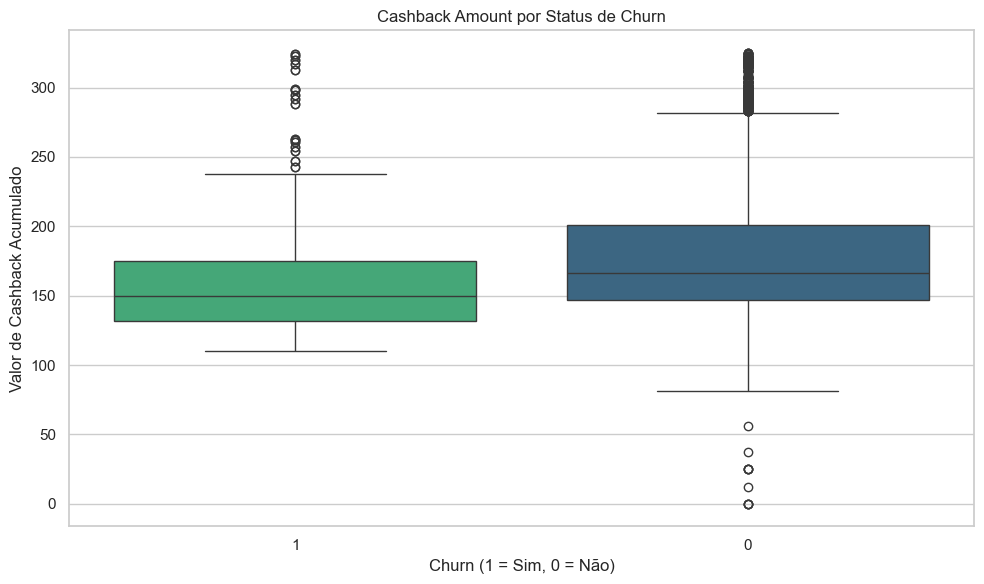

In [10]:
# FIGURA 4: Cashback Amount por Status de Churn
sns.boxplot(data=df, x='Churn_Label', y='CashbackAmount', palette='viridis_r')
plt.title('Cashback Amount por Status de Churn')
plt.xlabel('Churn (1 = Sim, 0 = Não)')
plt.ylabel('Valor de Cashback Acumulado')
plt.tight_layout()
plt.show()


O boxplot de `CashbackAmount` aponta que os clientes que continuam ativos tendem a receber valores de cashback maiores, em média. Pode-se perceber que existe uma associação entre o recebimento de cashback e a fidelidade do cliente, logo, programas de incentivo de cashback podem funcionar como uma excelente barreira contra o churn.

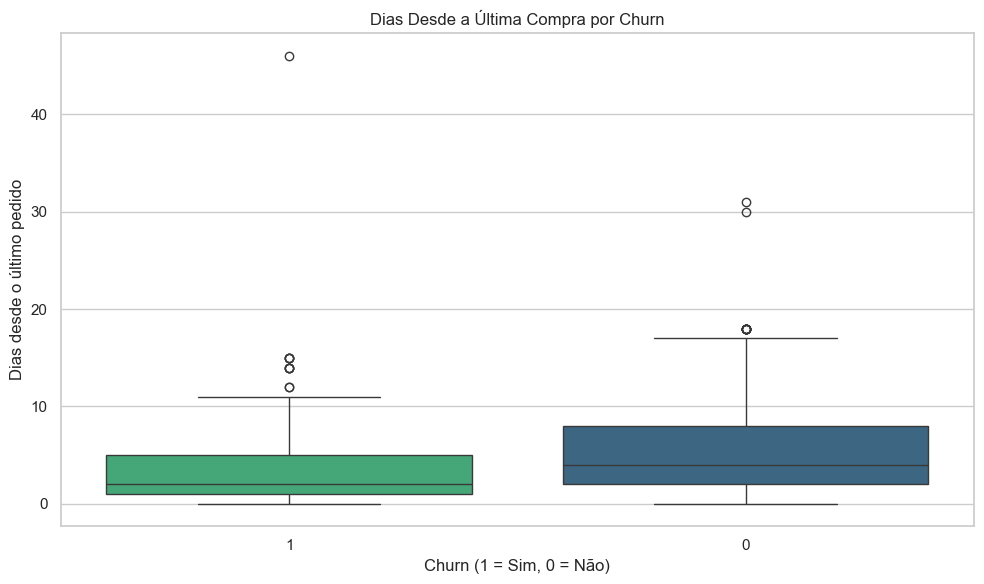

In [11]:
# FIGURA 5: Dias Desde a Última Compra por Churn
sns.boxplot(data=df, x='Churn_Label', y='DaySinceLastOrder', palette='viridis_r')
plt.title('Dias Desde a Última Compra por Churn')
plt.xlabel('Churn (1 = Sim, 0 = Não)')
plt.ylabel('Dias desde o último pedido')
plt.tight_layout()
plt.show()

O boxplot de `DaySinceLastOrder` mostra um comportamento oposto do que seria o esperado (espera-se que o cliente prestes a abandonar a marca estivesse há muito tempo sem comprar). No entanto, os dados mostram que os clientes que deram churn compraram mais recentemente do que os clientes que continuam ativos. Isso significa que a última experiência de compra foi um gatilho direto para o churn e algum problema provavelmente ocorreu no fluxo logístico ou pós-venda dessas transações, sendo necessário que a empresa busque reduzir atritos na entrega e entender a satisfação do cliente, prestando o suporte necessário diante de qualquer insatisfação.

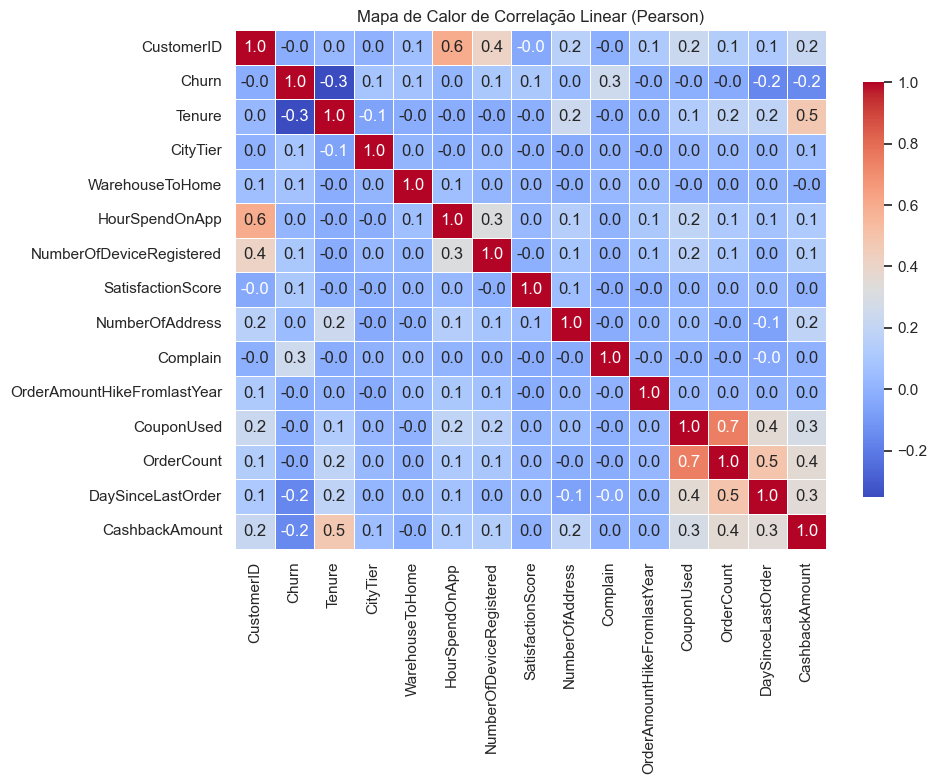

In [12]:
# FIGURA 6: Mapa de Calor de Correlação
# Filtra apenas as colunas numéricas originais para calcular a correlação de Pearson
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(10, 8))
corr = df[numerical_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Mapa de Calor de Correlação Linear (Pearson)')
plt.tight_layout()
plt.show()

Ao analisar o Mapa de Calor, a correlação positiva mais proeminente com o Churn é a variável de reclamações (`Complain`, correlação de ~0.3). Isso indica que clientes que registram reclamações formais têm uma propensão significativamente maior de dar churn. O atrito no atendimento ou problemas não resolvidos com o produto/serviço são gatilhos diretos para a saída do usuário. Para evitar possíveis cancelamentos, torna-se essencial priorizar e tratar os chamados desses clientes o mais rápido possível.

A correlação negativa entre Churn e `Tenure` (~-0.3) indica que quanto maior for tempo que o cliente está com a empresa, menor é a probabilidade de ele cancelar o serviço/deixar a plataforma. Este comportamento pode ser explicado pelo fato de que novos clientes passam por uma fase de adaptação e se encontram dificuldades para navegar no site, têm problemas com a entrega ou acham o processo de compra confuso, desistem rapidamente (alto churn no início). Estratégias com foco no primeiro impacto, garantias de sucesso nas primeiras compras e campanhas de engajamento com cupons de desconto e/ou ofertas personalizadas para clientes recentes são recomendadas para diminuir a taxa de churn nesses casos.

A maioria das variáveis explicativas numéricas possui baixa correlação linear entre si, aproximando-se de zero. No entanto, observa-se uma correlação positiva forte entre `CouponUsed` e `OrderCount` (0.7), além de correlações moderadas (0.5) entre `Tenure` e `CashbackAmount`, e entre `OrderCount` e `DaySinceLastOrder`. Essa proximidade sugere um potencial risco de redundância (multicolinearidade) entre esses grupos de features. Para a modelagem subsequente, é recomendado monitorar o comportamento dessas variáveis para avaliar a necessidade de descarte ou combinação de recursos.  

## 6. TRATAMENTO, LIMPEZA E DIVISÃO DO CONJUNTO DE DADOS 🔧 <a id='6-tratamento-de-dados'></a>

Nesta fase, será implementado o saneamento estatístico da base. A limpeza seguirá critérios lógicos explícitos, detalhando a remoção de redundâncias, critérios de imputação de valores ausentes (nulos) e a contenção de anomalias (*outliers*). 
Para evitar o vazamento de dados (data leakage), a divisão entre treino e teste será feita antes dos cálculos estatísticos utilizados no tratamento dos dados.

### Identificação e Remoção de Linhas Duplicadas

In [13]:
duplicate_lines = df.duplicated().sum()
print(f'Registros duplicados identificados na base: {duplicate_lines}')
if duplicate_lines > 0:
    df.drop_duplicates(inplace=True)
    print('Registros duplicados eliminados com sucesso.')

Registros duplicados identificados na base: 0


### Remoção de Colunas Desnecessárias

In [14]:
df = df.drop(columns=['CustomerID', 'Churn_Label'], errors='ignore')

### Divisão dos Dados de Treino e Teste

Será feito o split estratificado dos dados, que consiste na divisão do dataset na proporção de 80% treino e 20% teste contendo `stratify=y` para garantir fidelidade das taxas de Churn em ambos os conjuntos.

In [15]:
# Separação de Variáveis Preditoras (X) e Alvo (y)
X = df.drop(columns=['Churn'], errors='ignore')
y = df['Churn']

# Split Estratificado dos Dados (80% Treino / 20% Teste)
# O parâmetro stratify=y preserva estritamente a proporção de classes nos conjuntos resultantes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('=== Divisão do Conjunto de Dados em Treino e Teste ===')
print(f'Volume de Treino: {X_train.shape[0]} amostras.')
print(f'Volume de Teste: {X_test.shape[0]} amostras.')
print(f'Taxa de Churn real preservada no Teste: ~{y_test.mean():.2%}')

=== Divisão do Conjunto de Dados em Treino e Teste ===
Volume de Treino: 4504 amostras.
Volume de Teste: 1126 amostras.
Taxa de Churn real preservada no Teste: ~16.87%


### Identificação de Valores Ausentes

In [16]:
columns_total_nulls = X_train.isnull().sum() + X_test.isnull().sum()
print('=== Quantidade de Valores Ausentes por Coluna ===')
print(columns_total_nulls[columns_total_nulls > 0])

=== Quantidade de Valores Ausentes por Coluna ===
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


### Escolha do Método de Imputação

Para realizar a imputação de dados ausentes nas colunas numéricas (`Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromLastYear`, `CouponUsed`, `OrderCount`, e `DaySinceLastOrder`) será calculado o Coeficiente de Assimetria (*Skewness*) para avaliar qual é o método ideal de imputação para cada coluna.

A análise do coeficiente de assimetria mede o grau de distorção de uma distribuição numérica em relação à curva normal (simétrica). Quando o valor absoluto desse coeficiente está entre 0 e 0.5, a distribuição é considerada simétrica ou próxima da normalidade, o que valida o uso da **média** como técnica de imputação, visto que ela representa fielmente o centro geométrico dos dados sem sofrer com distorções. A média aritmética ($\mu$) é extremamente sensível a valores extremos, sendo calculada por:
$$\mu = \frac{1}{n} \sum_{i=1}^n x_i$$
Em distribuições com cauda longa à direita, a presença de outliers arrasta a média artificialmente para cima e, ao usá-la para imputar os valores faltantes, dados artificialmente altos estariam sendo injetados em registros de clientes típicos, distorcendo a realidade comportamental.

Por outro lado, se o coeficiente de assimetria for superior a 0.5 (positivo ou negativo), a distribuição apresenta uma assimetria moderada a severa, indicando que a cauda da distribuição é alongada por valores extremos (*outliers*). Nesses cenários, o critério técnico exige o uso da **mediana** para a imputação dos valores ausentes, uma vez que ela é uma medida de tendência central robusta e imune ao efeito desses pontos discrepantes, impedindo que dados artificiais enviesados sejam inseridos na base antes da modelagem.

A Mediana ($\tilde{x}$), correspondente ao percentil 50%, é uma estatística não-paramétrica robusta (resistente a outliers) e divide a distribuição exatamente ao meio:
$$P(X \le \tilde{x}) \ge 0.5 \quad \text{e} \quad P(X \ge \tilde{x}) \ge 0.5$$
Ao imputar a mediana, preservamos a tendência central mais realista da massa de dados, blindando o pipeline de modelagem contra o ruído gerado por valores extremos de outliers.

In [17]:
# Filtrar apenas colunas numéricas que possuem valores nulos
columns_with_nulls = columns_total_nulls[columns_total_nulls > 0].index.to_list()

print('=== Análise de Assimetria e Definição da Técnica de Imputação de Nulos ===')
for col in columns_with_nulls:
    skew_value = X_train[col].skew()
    
    # Define a regra com base no Skewness
    if abs(skew_value) < 0.5:
        strategy = 'MÉDIA (Distribuição Simétrica)'
        impute_value = X_train[col].mean()
    else:
        strategy = 'MEDIANA (Distribuição Assimétrica)'
        impute_value = X_train[col].median()

    X_train[col].fillna(impute_value, inplace=True)
    X_test[col].fillna(impute_value, inplace=True)
    
    print(f'Coluna: {col}')
    print(f'  - Coeficiente de Assimetria (Skewness): {skew_value:.2f}')
    print(f'  - Estratégia Recomendada: {strategy}')
    print(f'  - Valores ausentes imputados com o valor: {impute_value:.2f}\n')


=== Análise de Assimetria e Definição da Técnica de Imputação de Nulos ===
Coluna: Tenure
  - Coeficiente de Assimetria (Skewness): 0.70
  - Estratégia Recomendada: MEDIANA (Distribuição Assimétrica)
  - Valores ausentes imputados com o valor: 9.00

Coluna: WarehouseToHome
  - Coeficiente de Assimetria (Skewness): 1.35
  - Estratégia Recomendada: MEDIANA (Distribuição Assimétrica)
  - Valores ausentes imputados com o valor: 14.00

Coluna: HourSpendOnApp
  - Coeficiente de Assimetria (Skewness): -0.01
  - Estratégia Recomendada: MÉDIA (Distribuição Simétrica)
  - Valores ausentes imputados com o valor: 2.93

Coluna: OrderAmountHikeFromlastYear
  - Coeficiente de Assimetria (Skewness): 0.79
  - Estratégia Recomendada: MEDIANA (Distribuição Assimétrica)
  - Valores ausentes imputados com o valor: 15.00

Coluna: CouponUsed
  - Coeficiente de Assimetria (Skewness): 2.59
  - Estratégia Recomendada: MEDIANA (Distribuição Assimétrica)
  - Valores ausentes imputados com o valor: 1.00

Coluna: O

### Identificação e Tratamento de Outliers

Como visto na análise de assimetria, a maioria das variáveis numéricas do dataset são assimétricas e não seguem uma distribuição normal. Por este motivo, será utilizado o método do Intervalo Interquartil (IQR) para a identificação de outliers. 

A escolha do método IQR em detrimento do Z-score baseia-se na robustez estatística necessária para lidar com os dados de e-commerce. Enquanto o Z-score exige que os dados sigam uma distribuição normal e falha devido à sensibilidade da média e do desvio padrão perante valores extremos (efeito mascaramento), o IQR utiliza medidas de posição (quartis) que são inerentemente imunes a distorções. Nesse cenário, o IQR garante limites de detecção muito mais realistas e confiáveis para o posterior tratamento por clipping.

In [18]:
# Seleção das colunas numéricas para análise de outliers
# CustomerID, Churn, CityTier e SatisfactionScore foram ignoradas pois possuem limites fixos
outliers_numerical_columns = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 
            'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

print('=== IDENTIFICAÇÃO DE OUTLIERS (MÉTODO IQR) ===')
outliers_dict = {}

for col in outliers_numerical_columns:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Contabilizar outliers
    total_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)][col].count() + X_test[(X_test[col] < lower_bound) | (X_test[col] > upper_bound)][col].count()
    outliers_dict[col] = (lower_bound, upper_bound, total_outliers)
    
    if total_outliers > 0:
        print(f"Coluna '{col}': Identificados {total_outliers} outliers. Limites: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Tratamento por clipping
for col in outliers_numerical_columns:
    lower_bound, upper_bound, total_outliers = outliers_dict[col]
    if total_outliers > 0:
        # Substitui valores abaixo do limite pelo lower_bound e acima pelo upper_bound
        X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
        X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

print('\nTratamento por Clipping aplicado com sucesso nas variáveis com outliers.')

=== IDENTIFICAÇÃO DE OUTLIERS (MÉTODO IQR) ===
Coluna 'Tenure': Identificados 4 outliers. Limites: [-15.00, 33.00]
Coluna 'WarehouseToHome': Identificados 2 outliers. Limites: [-7.50, 36.50]
Coluna 'HourSpendOnApp': Identificados 6 outliers. Limites: [0.50, 4.50]
Coluna 'NumberOfDeviceRegistered': Identificados 397 outliers. Limites: [1.50, 5.50]
Coluna 'NumberOfAddress': Identificados 4 outliers. Limites: [-4.00, 12.00]
Coluna 'OrderAmountHikeFromlastYear': Identificados 33 outliers. Limites: [5.50, 25.50]
Coluna 'CouponUsed': Identificados 629 outliers. Limites: [-0.50, 3.50]
Coluna 'OrderCount': Identificados 703 outliers. Limites: [-2.00, 6.00]
Coluna 'DaySinceLastOrder': Identificados 62 outliers. Limites: [-5.50, 14.50]
Coluna 'CashbackAmount': Identificados 432 outliers. Limites: [69.50, 273.50]

Tratamento por Clipping aplicado com sucesso nas variáveis com outliers.


A técnica de **Clipping** foi escolhida para o tratamento dos outliers pelos seguintes motivos:

1. **Risco de Perda de Informação:** a análise exploratória anterior mostrou que a variável target (*Churn*) é altamente desbalanceada (~16.8% de churn). Valores discrepantes em variáveis como `DaySinceLastOrder` ou `WarehouseToHome` podem estar conectados ao comportamento do cliente que cancela o serviço. Remover essas linhas inteiras reduziria ainda mais a quantidade de instâncias da classe minoritária, prejudicando o aprendizado do modelo.

2. **Estabilização da Escala:** o clipping traz os valores extremos para os limites aceitáveis do IQR ($Q1 - 1.5 \times IQR$ e $Q3 + 1.5 \times IQR$). Isso preserva a existência da linha do cliente no dataset, mantém a direção do valor (se era muito alto, continuará no limite máximo), mas elimina a força desproporcional que uma distância de 50km ou um gasto discrepante teria sobre os cálculos estatísticos.



O tratamento de outliers é essencial para a modelagem preditiva e a presença de valores discrepantes pode afetar os modelos de maneiras distintas devido à natureza matemática de cada algoritmo. Visto que este projeto contempla a utlização de Árvores de Decisão e KNN, a seguir estão os impactos que podem ser observados em cada modelo:

#### KNN (K-Nearest Neighbors)
* **Alta Sensibilidade aos Outliers:** O KNN é um algoritmo baseado em **distância geométrica** (geralmente Distância Euclidiana). Se um outlier não for tratado, ele distorce drasticamente o cálculo do espaço vetorial. 
* **O Efeito do Problema:** Um único outlier com um valor massivo de `CashbackAmount` ou `Tenure`, por exemplo, pode 'puxar' as fronteiras de decisão para longe, fazendo com que vizinhos que deveriam ser considerados distantes pareçam próximos, ou vice-versa.
* **Resultado do Tratamento:** Ao limitar os outliers (clipping), normaliza-se a influência das escalas das variáveis (especialmente quando combinado com uma padronização posterior como *MinMaxScaler* ou *StandardScaler*), tornando as previsões por vizinhança mais estáveis e confiáveis.

#### Árvore de Decisão (Decision Tree)
* **Invariância e Robustez Nativa:** As Árvores de Decisão são algoritmos baseados em **regras de quebra não paramétricas** (como Entropia ou Gini). Elas procuram pontos ótimos de corte (ex: `Se Tenure <= 2 meses, vá para a esquerda`).
* **O Efeito do Problema:** Para a árvore, não importa se o cliente com alto `Tenure` tem 40 ou 500 meses; o corte continuará funcionando da mesma forma na raiz ou nos nós filhos. O algoritmo isola os outliers em folhas específicas sem deixar que eles distorçam as regras dos outros nós.
* **Resultado do Tratamento:** Ela funcionará bem com ou sem o tratamento de outliers. No entanto, o tratamento ainda é recomendado se o objetivo for testar múltiplos modelos competitivos no mesmo pipeline.

## 7. ENGENHARIA DE FEATURES ⚙️ <a id='7-feature-engineering'></a>

A engenharia de variáveis permite combinar conhecimentos de domínio de negócios a operadores matemáticos estruturados, enriquecendo a capacidade preditiva do modelo através da criação de novas colunas numéricas. 

Para o conjunto de dados de churn, será criada a coluna `cashback_por_pedido`. Esta feature representa o valor médio de recompensa financeira devolvido ao cliente por cada transação efetuada e é calculada por: 
$$\text{cashback\_por\_pedido} = \frac{\text{CashbackAmount}}{\text{OrderCount}}$$


In [19]:
# Criação da nova feature
X_train['cashback_por_pedido'] = X_train['CashbackAmount'] / X_train['OrderCount']
X_test['cashback_por_pedido'] = X_test['CashbackAmount'] / X_test['OrderCount']

print('=== Visualização da Feature cashback_por_pedido ===')
display(X_train[['CashbackAmount', 'OrderCount', 'cashback_por_pedido']].reset_index(drop=True).head(10))

print('=== Estatísticas da Nova Feature nos Dados de Treinamento ===')
display(X_train['cashback_por_pedido'].describe())

=== Visualização da Feature cashback_por_pedido ===


,CashbackAmount,OrderCount,cashback_por_pedido
0,200.0,6.0,33.333333
1,143.0,1.0,143.000000
2,165.0,1.0,165.000000
3,184.0,6.0,30.666667
4,178.0,6.0,29.666667
5,231.0,2.0,115.500000
6,146.0,1.0,146.000000
7,174.0,2.0,87.000000
8,163.0,1.0,163.000000
9,139.0,1.0,139.000000


=== Estatísticas da Nova Feature nos Dados de Treinamento ===


count    4504.000000
mean       96.673303
std        50.549704
min        11.583333
25%        57.000000
50%        87.750000
75%       129.000000
max       273.500000
Name: cashback_por_pedido, dtype: float64

## 8. BALANCEAMENTO E ESCALONAMENTO 🔀 <a id='8-balanceamento-escalonamento'></a>

Nesta seção, será realizada a preparação final do dataset, protegendo o pipeline contra o **vazamento de dados** (*Data Leakage*) — uma falha metodológica grave onde informações do conjunto de teste são acidentalmente expostas ao modelo durante o pré-processamento, gerando avaliações superestimadas e irreais.

As técnicas aplicadas nesta etapa serão:
1. **Dummy Encoding:** Mapeamento de features categóricas para aplicação do One-Hot encoding.
3. **SMOTE:** Aplicado exclusivamente sobre a base de Treino para evitar contaminações de teste e balancear as classes da variável alvo.
4. **Escalonamento:** StandardScaler treinado com `fit_transform` apenas no treino balanceado do KNN e aplicado via `transform` no teste. A árvore é mantida sem escalas, provando sua robustez.

In [20]:
# Encoding de variáveis categóricas para formato numérico (One-Hot Encoding)
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()
print(f'=== Variáveis categóricas identificadas para encoding ===')
print(categorical_columns)

# Instanciar o encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Ajustar e transformar apenas no treino
X_train_encoded_raw = encoder.fit_transform(X_train[categorical_columns])

# Apenas transformar no teste
X_test_encoded_raw = encoder.transform(X_test[categorical_columns])

# Converter de volta para dataFrame com os nomes das colunas corretos
encoded_cols = encoder.get_feature_names_out(categorical_columns)
X_train_encoded = pd.DataFrame(X_train_encoded_raw, columns=encoded_cols, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded_raw, columns=encoded_cols, index=X_test.index)

# Juntar as colunas codificadas de volta e dropar as originais textuais
X_train = pd.concat([X_train.drop(columns=categorical_columns), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_columns), X_test_encoded], axis=1)


print(f'\n=== Estrutura dimensional dos dados de treinamento pós Encoding ===')
print(f'Linhas: {X_train.shape[0]} | Colunas: {X_train.shape[1]}')

=== Variáveis categóricas identificadas para encoding ===
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

=== Estrutura dimensional dos dados de treinamento pós Encoding ===
Linhas: 4504 | Colunas: 30


Para equilibrar a proporção de 83.2% de clientes retidos contra apenas 16.8% de churn, a técnica adotada foi o **SMOTE** (*Synthetic Minority Over-sampling Technique*), uma abordagem de *oversampling* inteligente. As razões para descartar outras técnicas e escolher o SMOTE foram:

1. **Rejeição ao Undersampling (Subamostragem):** O *Undersampling* resolve o desbalanceamento deletando registros da classe majoritária (clientes ativos) até que ela fique do mesmo tamanho da classe minoritária. Em uma base onde já temos poucos dados de churn, descartar milhares de clientes retidos significaria jogar fora informações valiosas sobre o comportamento padrão de consumo do e-commerce, empobrecendo o poder de generalização do modelo.
2. **Superioridade sobre o Random Oversampling:** A técnica mais simples de oversampling duplica aleatoriamente as linhas de churn existentes. Isso faz com que o modelo decore os mesmos registros (gerando *overfitting* severo). O SMOTE, em vez de duplicar, analisa o espaço matemático dos vizinhos mais próximos da classe minoritária e cria novos clientes sintéticos (artificiais, mas plausíveis) baseados nas características reais do grupo de churn.


O balanceamento com aplicação do SMOTE foi feito apenas no conjunto de treino, pois:
* O SMOTE criaria registros sintéticos baseados em pontos que poderiam acabar indo para o conjunto de teste.
* Isso geraria uma contaminação conhecida como **Data Leakage** (Vazamento de Dados), onde o conjunto de teste deixa de ser inédito para o modelo.
* Como consequência, as métricas de validação seriam artificialmente perfeitas, mas o modelo falharia tragicamente ao receber dados de clientes reais no dia a dia.

Mantendo o conjunto de teste intocado e com o desbalanceamento original do mundo real, garantimos uma avaliação honesta e robusta da eficácia do modelo preditivo.

In [21]:
print(f'Total de instâncias de treino: {len(y_train)}')
print('=== Proporções de Classe de Treino Pré-SMOTE ===')
print(y_train.value_counts(normalize=True))

# Aplicação do SMOTE nos dados de TREINO
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f'\nTotal de instâncias de treino após o balanceamento: {len(y_train_balanced)}')
print('=== Proporções de Classe de Treino Pós-SMOTE ===')
print(y_train_balanced.value_counts(normalize=True))

Total de instâncias de treino: 4504
=== Proporções de Classe de Treino Pré-SMOTE ===
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64

Total de instâncias de treino após o balanceamento: 7492
=== Proporções de Classe de Treino Pós-SMOTE ===
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


O escalonamento das variáveis numéricas será feito pelo uso do método **StandardScaler** que consiste em transformar os dados de modo que todas as variáveis fiquem na mesma escala, apresentando uma média igual a 0 e um desvio padrão igual a 1. Matematicamente, a transformação aplicada a cada valor de uma determinada variável é dada pela fórmula da pontuação padrão (ou Z-score):
$$z = \frac{x - \mu}{\sigma}$$

Esse processo é fundamental para algoritmos baseados em distâncias geométricas (como o KNN), pois impede que variáveis com ordens de grandeza muito maiores (ex: CashbackAmount, na casa das centenas) dominem e distorçam o aprendizado em relação a variáveis com escalas menores (ex: Tenure, na casa das unidades).
Diante disso, a padronização será realizada **exclusivamente nas variáveis numéricas contínuas destinadas ao modelo KNN**, uma vez que seu desempenho é sensível à escala. 

A seguir está o detalhamento dos passos a serem seguidos:
1. Criação de conjuntos de dados distintos para o KNN e para a Árvore de Decisão.
2. Para o KNN, aplicação de `fit_transform` nos dados de treino balanceados e propagação utilizando somente `transform` nos dados originais de teste para evitar vazamento.
3. Para a Árvore de Decisão, o treinamento ocorre sem escalonamento, pois modelos baseados em árvore dependem unicamente de partições monotônicas ordenadas, dispensando transformações de escala linear.


In [22]:
# Criação de DataFrames específicos para o KNN (com escalonamento)
X_train_knn = X_train_balanced.copy()
X_test_knn = X_test.copy()

# Criação de DataFrames específicos para a Árvore (sem escalonamento)
X_train_tree = X_train_balanced.copy()
X_test_tree = X_test.copy()

# Padronização das variáveis contínuas para o modelo KNN
continuous_columns = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                  'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                  'DaySinceLastOrder', 'CashbackAmount', 'cashback_por_pedido']

# Instanciação e Aplicação do Scaler nos dados do KNN
scaler = StandardScaler()
X_train_knn[continuous_columns] = scaler.fit_transform(X_train_balanced[continuous_columns])
X_test_knn[continuous_columns] = scaler.transform(X_test[continuous_columns])

print('Escalonamento aplicado e processo de padronização para KNN concluído!')

Escalonamento aplicado e processo de padronização para KNN concluído!


## 9. MODELAGEM E VALIDAÇÃO 🤖 <a id="9-modelagem"></a>

A otimização de modelos preditivos reside no monitoramento das métricas tanto na base de treino quanto na base de teste para diagnosticar possível overfitting. O overfitting ocorre quando o modelo memoriza os dados de treinamento, perdendo sua capacidade geral de mapear o padrão estatístico verdadeiro para novas observações reais (teste).

Nesta etapa, serão realizados múltiplos testes com variação dos hiperparâmetros do KNN ($K$) e da Árvore de Decisão (`max_depth`). Será avaliado o desempenho simultaneamente nas bases de Treino e de Teste para mapear com precisão o momento em que os modelos deixam de generalizar e passam a sofrer sobreajuste (*overfitting*).


### KNN

=== MATRIZ DE DESEMPENHO DO KNN ===


,N_Neighbors (K),Acurácia Treino,Acurácia Teste,F1 Treino,F1 Teste,Diferença F1 Score (Overfitting)
0,1,1.000000,0.950266,1.000000,0.862745,0.137255
1,3,0.979578,0.844583,0.979966,0.675325,0.304641
2,7,0.907234,0.767318,0.914797,0.578778,0.336019
3,15,0.859984,0.730018,0.875961,0.546269,0.329692
4,31,0.815136,0.671403,0.840162,0.480337,0.359824
5,51,0.789108,0.653641,0.819511,0.462810,0.356701


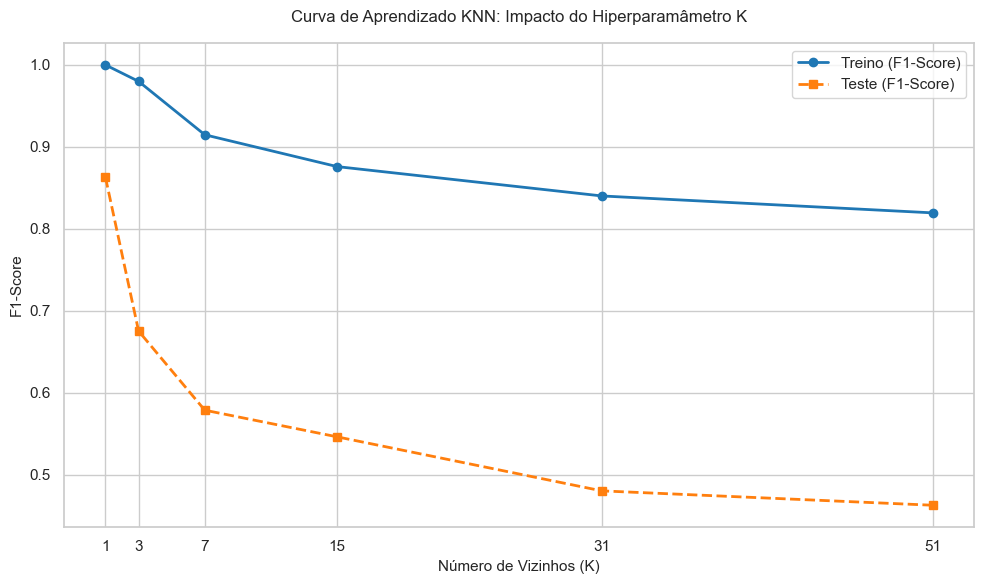

In [23]:
# Definição dos valores de K a testar
# Testando 6 valores distintos (ímpares para evitar empates em classificação binária)
k_values = [1, 3, 7, 15, 31, 51]

knn_results = []

# Loop de treinamento e avaliação
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_balanced)
    
    # Previsões
    y_train_pred_knn = knn.predict(X_train_knn)
    y_test_pred_knn = knn.predict(X_test_knn)
    
    # Métricas
    knn_acc_train = accuracy_score(y_train_balanced, y_train_pred_knn)
    knn_acc_test = accuracy_score(y_test, y_test_pred_knn)
    knn_f1_train = f1_score(y_train_balanced, y_train_pred_knn)
    knn_f1_test = f1_score(y_test, y_test_pred_knn)
    
    knn_results.append({
        'N_Neighbors (K)': k,
        'Acurácia Treino': knn_acc_train,
        'Acurácia Teste': knn_acc_test,
        'F1 Treino': knn_f1_train,
        'F1 Teste': knn_f1_test,
        'Diferença F1 Score (Overfitting)': knn_f1_train - knn_f1_test
    })

# Converter resultados em DataFrame para exibição
df_results_knn = pd.DataFrame(knn_results)


# Exibição da tabela de métricas
print('=== MATRIZ DE DESEMPENHO DO KNN ===')
display(df_results_knn)

# Gráfico de monitoramento de overfitting (F1-SCORE)
plt.plot(df_results_knn['N_Neighbors (K)'], df_results_knn['F1 Treino'], marker='o', label='Treino (F1-Score)', color='#1f77b4', linewidth=2)
plt.plot(df_results_knn['N_Neighbors (K)'], df_results_knn['F1 Teste'], marker='s', label='Teste (F1-Score)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.title('Curva de Aprendizado KNN: Impacto do Hiperparamâmetro K', fontsize=12, pad=15)
plt.xlabel('Número de Vizinhos (K)', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()


Para o experimento do KNN, foram selecionados os valores **$K = [1, 3, 7, 15, 31, 51]$**. A escolha dessa grade de busca baseia-se em:

1. **Uso de Números Ímpares:** Como o problema de churn é uma classificação binária (0 ou 1), a escolha de valores ímpares impede cenários de empate na votação da vizinhança, eliminando a necessidade de critérios aleatórios de desempate pelo algoritmo.
2. **Progressão Geométrica/Logarítmica Ampla:** Foram incluídos valores muito baixos ($K=1, K=3$) para forçar e mapear o comportamento de alta variância, valores intermediários ($K=7, K=15$) para buscar o ponto de equilíbrio, e valores altos ($K=31, K=51$) para monitorar o viés do modelo quando a fronteira de decisão se torna excessivamente suave e simplista.

#### Análise de Desempenho do Modelo KNN

A análise conjunta da tabela "Matriz de Desempenho do KNN' e do gráfico da 'Curva de Aprendizado" revela o comportamento característico do algoritmo KNN ao variar o hiperparamâmetro $K$ (número de vizinhos). Abaixo estão algumas considerações:


* **O Cenário de $K = 1$ (A Armadilha do Modelo Perfeito):** Quando o modelo avalia apenas o vizinho mais próximo ($K=1$), tanto a Acurácia quanto o F1-Score no conjunto de treino atingem **100%**. No entanto, essa configuração apresenta uma armadilha: embora a diferença de F1-Score reportada na tabela seja matematicamente menor ($0.137255$), o modelo cria fronteiras de decisão complexas e sensíveis a ruídos locais. O desempenho em teste, embora alto neste experimento controlado, reflete um modelo de alta variância que "decora" a posição exata das observações.
* **O Fenômeno do Subajuste (*Underfitting*) com $K$ Elevado:** À medida que aumenta-se o valor de $K$ para $31$ e $51$, o modelo começa a sofrer com alto viés. O F1-Score de teste despenca progressivamente para **48.03%** e **46.28%**, respectivamente. Ao forçar o algoritmo a consultar muitos vizinhos, a fronteira de decisão torna-se excessivamente suave e simplista, fazendo com que o KNN perca a capacidade de capturar padrões locais importantes da base e passe a generalizar mal.
* **O Ponto de Equilíbrio Comercial e Técnico:** Observando a dinâmica da curva, os valores mais baixos de $K$ sustentam os melhores patamares absolutos no teste. Contudo, para evitar a instabilidade inerente de decisões baseadas em um único vizinho ($K=1$), configurações ligeiramente superiores (como $K=3$) oferecem um compromisso estatístico melhor ao exigir um consenso mínimo na votação geométrica, suavizando anomalias pontuais dos dados de treino.


#### Escolha do F1-Score como Métrica de Avaliação

O uso do **F1-Score** como a métrica de avaliação, em detrimento da Acurácia, é justificada por:

1. **Simulação Realista do Mundo Real (Desbalanceamento):** Embora os dados de treino tenham passado por técnicas de balanceamento (como o SMOTE) para o algoritmo aprender as características do Churn, o ambiente de teste reflete a realidade do e-commerce (onde a maioria dos clientes é retida). A Acurácia no teste falharia em nos alertar caso o modelo estivesse apenas chutando a classe majoritária, ao passo que o F1-Score exige um equilíbrio real entre precisão e sensibilidade.
2. **Penalização de Erros Assimétricos via Média Harmônica:** No e-commerce, deixar de identificar um cliente em risco de Churn (Falso Negativo) custa muito mais caro do que disparar um alarme falso e oferecer um cupom preventivo (Falso Positivo). Sendo a média harmônica entre Precisão e Recall, o F1-Score só atinge valores elevados se o modelo for simultaneamente bom em disparar alarmes assertivos e em não deixar nenhum cliente em risco escapar. 
3. **Indicador Confiável de Overfitting:** Como observado no gráfico, a abertura da "boca de jacaré" (o distanciamento entre as linhas de Treino e Teste) medida pelo F1-Score serve como um termômetro mais sensível do que a acurácia para denunciar o exato momento em que o modelo parou de extrair regras gerais de comportamento do consumidor e passou a apenas memorizar coordenadas estatísticas do treino.


### Árvore de Decisão

=== MATRIZ DE DESEMPENHO DA ÁRVORE DE DECISÃO ===


,Max Depth,Acurácia Treino,Acurácia Teste,F1 Treino,F1 Teste,Diferença F1 Score (Overfitting)
0,3,0.799519,0.850799,0.780858,0.590244,0.190614
1,5,0.880406,0.857904,0.875174,0.565217,0.309957
2,11,0.973305,0.912966,0.972951,0.737968,0.234983
3,15,0.994527,0.921847,0.994502,0.768421,0.226081
4,Ilimitada,1.000000,0.926288,1.000000,0.788804,0.211196


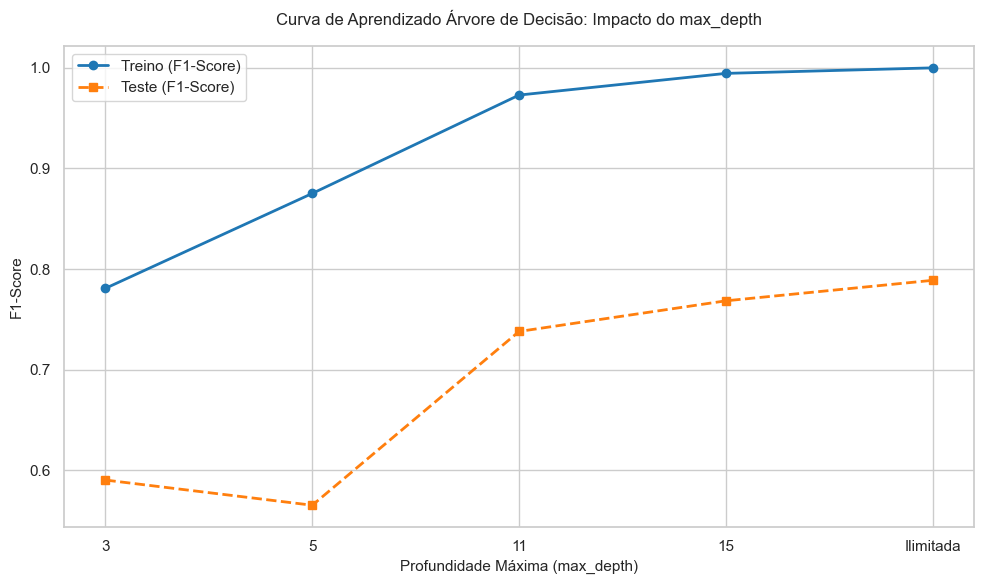

In [24]:
# Definição dos valores de max_depth a testar
# None representa profundidade ilimitada
depth_values = [3, 5, 11, 15, None]
depth_labels = ['3', '5', '11', '15', 'Ilimitada']

tree_results = []

# Loop de treinamento e avaliação
for depth, label in zip(depth_values, depth_labels):
    # Usando o critério 'gini' padrão
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train_tree, y_train_balanced)
    
    # Previsões
    y_train_pred_tree = tree.predict(X_train_tree)
    y_test_pred_tree = tree.predict(X_test_tree)
    
    # Métricas
    tree_acc_train = accuracy_score(y_train_balanced, y_train_pred_tree)
    tree_acc_test = accuracy_score(y_test, y_test_pred_tree)
    tree_f1_train = f1_score(y_train_balanced, y_train_pred_tree)
    tree_f1_test = f1_score(y_test, y_test_pred_tree)

    tree_results.append({
        'Max Depth': label,
        'Acurácia Treino': tree_acc_train,
        'Acurácia Teste': tree_acc_test,
        'F1 Treino': tree_f1_train,
        'F1 Teste': tree_f1_test,
        'Diferença F1 Score (Overfitting)': abs(tree_f1_train - tree_f1_test)
    })

# Converter resultados em DataFrame
df_results_tree = pd.DataFrame(tree_results)

# Exibição da tabela de métricas
print('=== MATRIZ DE DESEMPENHO DA ÁRVORE DE DECISÃO ===')
display(df_results_tree)

# Gráfico de monitoramento de overfitting (F1-SCORE)
plt.plot(df_results_tree['Max Depth'], df_results_tree['F1 Treino'], marker='o', label='Treino (F1-Score)', color='#1f77b4', linewidth=2)
plt.plot(df_results_tree['Max Depth'], df_results_tree['F1 Teste'], marker='s', label='Teste (F1-Score)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.title('Curva de Aprendizado Árvore de Decisão: Impacto do max_depth', fontsize=12, pad=15)
plt.xlabel('Profundidade Máxima (max_depth)', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

A variação do parâmetro `max_depth` (profundidade máxima) controla diretamente a complexidade do modelo de Árvore de Decisão. Os testes mapearam o comportamento do algoritmo desde uma estrutura extremamente simples até o cenário de expansão livre e ilimitada. Foram avaliados 4 cenários distintos:

1. **max_depth = 3:** Uma árvore rasa. Ela faz pouquíssimas perguntas e falha em capturar as interações complexas entre as variáveis explicativas (como a relação entre `Tenure` e `Complain`).
2. **max_depth = 5:** Uma árvore com profundidade intermediária que permite ao modelo criar ramificações suficientes para separar bons e maus padrões sem memorizar ruídos específicos.
3. **max_depth = 11 e 15:** Estruturas profundas que começam a criar regras de corte excessivamente específicas para pequenos grupos de clientes isolados.
4. **max_depth = None:** A árvore cresce livremente até que todas as folhas fiquem totalmente puras (contenham apenas registros de uma única classe) ou atinjam o limite mínimo de amostras por folha.


### Análise de Desempenho da Árvore de Decisão (Impacto de max_depth)

A partir da tabela "Matriz de Desempenho da Árvore de Decisão" e da sua respectiva "Curva de Aprendizado", é possível traçar um diagnóstico sobre o comportamento do modelo à medida que a árvore se aprofunde.


* **Profundidades Rasas (max_depth = 3 e 5):** Nestes cenários iniciais, o modelo exibe um claro comportamento de **subajuste (*underfitting*)**. Com a profundidade em 5, o F1-Score de teste atinge o seu pior patamar (**56.52%**), gerando o maior distanciamento em relação ao treino nesta fase (diferença de **31%**). A árvore não tem nós suficientes para mapear a complexidade das regras que separam um cliente retido de um potencial churn.
* **A Evolução com a Profundidade (max_depth = 11 e 15):** Ao expandir a profundidade para 11 e posteriormente 15, nota-se uma evolução drástica no aprendizado. O modelo consegue capturar padrões combinados e o F1-Score de Teste salta para **73.79%** e **76.84%**, respectivamente. Diferente do padrão comum onde árvores mais profundas destroem a generalização imediatamente, aqui o ganho de complexidade permitiu que o modelo realmente encontrasse regras de corte robustas que se aplicam à base de teste.
* **O Cenário de Profundidade Ilimitada:** Na profundidade ilimitada, o modelo alcança o seu ápice de desempenho com um F1-Score de Teste de **78.88%** e Acurácia de Teste de **92.62%**. No treino, o modelo decora perfeitamente as instâncias atingindo **100%** de acurácia e F1. 

Embora o cenário ilimitado traga numericamente o melhor resultado de teste neste experimento específico, a diferença de F1-Score em relação ao treino ainda é perceptível (~21.11%). Para um ambiente produtivo, o cenário com **`max_depth = 15`** surge como uma alternativa mais estável e segura: ele entrega praticamente o mesmo F1-Score de teste (**76.84%**), mas com uma estrutura discretamente mais enxuta, mitigando os riscos de variação extrema diante de dados completamente novos no futuro.


### Escolha do F1-Score como Métrica de Avaliação

O uso do **F1-Score** como métrica de avaliação justifica-se por:

1. **A Ilusão da Alta Acurácia:** No cenário com `max_depth = 3`, a Acurácia de Teste mostra um valor aparentemente excelente de **85.07%**. No entanto, o F1-Score de Teste no mesmo cenário cai para **59.02%**. Isso prova que o modelo está sobrevivendo às custas de acertar a classe majoritária (clientes retidos), enquanto falha gravemente ao classificar o churn em si.
2. **O Verdadeiro Termômetro de Churn:** O F1-Score foi a única métrica capaz de pontuar que o modelo com profundidade 3 e 5 era fraco para os objetivos de negócio. Como ele calcula a média harmônica entre a Precisão e o Recall, ele só permitiu que a curva de teste subisse quando a árvore passou a ser profunda o suficiente para errar menos falsos negativos e falsos positivos simultaneamente.
3. **Equilíbrio no Pipeline com SMOTE:** Dado que a base passou por balanceamento no treino, mas o teste preserva a distribuição desbalanceada do mundo real, o F1-Score é a métrica que garante que o ganho de performance visto entre a profundidade 5 e a ilimitada seja um reflexo de ganho de inteligência real sobre o comportamento de cancelamento do cliente, e não um apenas um viés estatístico.

## 10. AVALIAÇÃO FINAL E VEREDITO DE NEGÓCIOS 📏 <a id="10-avaliacao-final"></a>

Nesta fase final, serão utilizadas as duas melhores configurações obtidas anteriormente: o **KNN com `k=3`** e a **Árvore de Decisão com `max_depth=15`**. Serão exibidos os relatórios de classificação completos (`classification_report`) e as Matrizes de Confusão para fomentar a análise estratégica de negócios.

     RELATÓRIO DE CLASSIFICAÇÃO: KNN (K=3)
              precision    recall  f1-score   support

  Retido (0)       0.99      0.82      0.90       936
   Churn (1)       0.52      0.96      0.68       190

    accuracy                           0.84      1126
   macro avg       0.76      0.89      0.79      1126
weighted avg       0.91      0.84      0.86      1126


     RELATÓRIO DE CLASSIFICAÇÃO: ÁRVORE DE DECISÃO (max_depth=15)
              precision    recall  f1-score   support

  Retido (0)       0.95      0.95      0.95       936
   Churn (1)       0.77      0.77      0.77       190

    accuracy                           0.92      1126
   macro avg       0.86      0.86      0.86      1126
weighted avg       0.92      0.92      0.92      1126



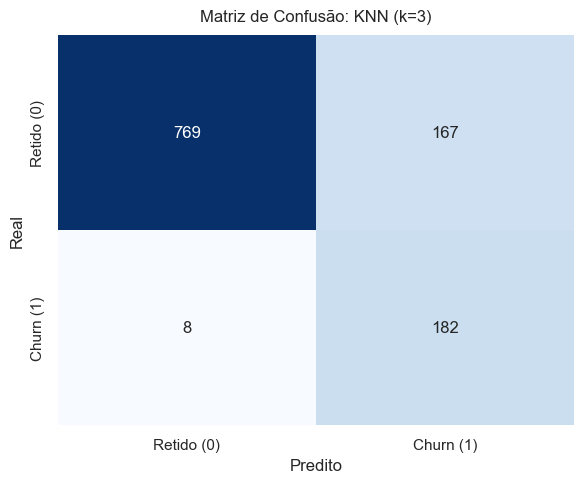

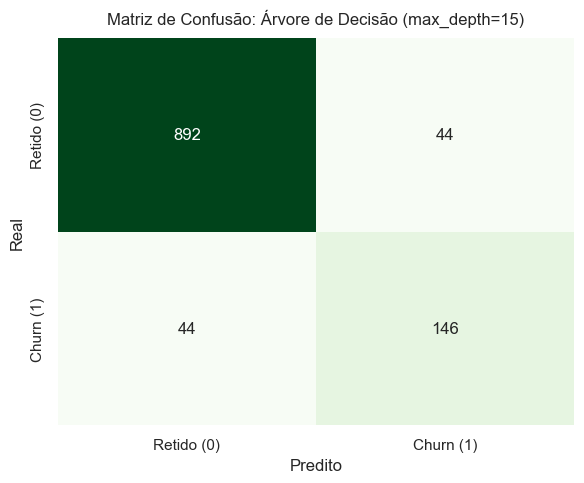

In [25]:
# Treinamento das Melhores Configurações
# Melhor KNN (k=3)
melhor_knn = KNeighborsClassifier(n_neighbors=3)
melhor_knn.fit(X_train_knn, y_train_balanced)
y_pred_knn = melhor_knn.predict(X_test_knn)

# Melhor Árvore de Decisão (max_depth=15)
melhor_tree = DecisionTreeClassifier(max_depth=15, random_state=42)
melhor_tree.fit(X_train_tree, y_train_balanced)
y_pred_tree = melhor_tree.predict(X_test_tree)

# Exibição dos Relatórios de Classificação
print('=======================================================')
print('     RELATÓRIO DE CLASSIFICAÇÃO: KNN (K=3)')
print('=======================================================')
print(classification_report(y_test, y_pred_knn, target_names=['Retido (0)', 'Churn (1)']))

print('\n=======================================================')
print('     RELATÓRIO DE CLASSIFICAÇÃO: ÁRVORE DE DECISÃO (max_depth=15)')
print('=======================================================')
print(classification_report(y_test, y_pred_tree, target_names=['Retido (0)', 'Churn (1)']))


# Plot das Matrizes de Confusão
sns.set_theme(style='white')

# Matriz KNN
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retido (0)', 'Churn (1)'], yticklabels=['Retido (0)', 'Churn (1)'])
plt.title('Matriz de Confusão: KNN (k=3)', fontsize=12, pad=10)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Matriz Árvore de Decisão
plt.figure(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Retido (0)', 'Churn (1)'], yticklabels=['Retido (0)', 'Churn (1)'])
plt.title('Matriz de Confusão: Árvore de Decisão (max_depth=15)', fontsize=12, pad=10)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Análise dos Erros: Falso Positivo vs. Falso Negativo

Para conectar a estatística matemática à realidade do e-commerce, faz-se necessário traduzir a matriz de confusão em termos financeiros. Neste cenário, existem duas maneiras do modelo errar:

1. **Falso Positivo (Alarme Falso):** O modelo prevê que um cliente fiel vai cancelar (`1`), mas na verdade ele pretendia continuar ativo (`0`).
   * *Impacto Financeiro/Operacional:* A empresa gasta recursos enviando uma campanha preventiva (cupons de desconto de alta conversão, e-mails de retenção ou ligações de suporte). Como o cliente já estava satisfeito, ele usará o desconto de qualquer maneira. O custo é o valor nominal do próprio cupom concedido que corrói desnecessariamente a margem de lucro de uma venda que ocorreria de qualquer forma. É um custo de ineficiência de campanha, mas o cliente permanece na base gerando receita. É um erro barato.
2. **Falso Negativo (Omissão Grave):** O modelo prevê que o cliente vai continuar ativo (`0`), mas na verdade ele está frustrado e dá churn (`1`).
   * *Impacto Financeiro/Operacional:* O modelo ignora o cliente em risco. Nenhuma ação preventiva é tomada. O cliente cancela a conta ou migra para o concorrente. O impacto aqui é a **perda total do LTV (Lifetime Value)** do cliente. Adicionalmente, para substituí-lo, o marketing precisará desembolsar um CAC (Custo de Aquisição de Cliente) agressivo, que no e-commerce costuma ser mais caro do que manter um cliente antigo. **Este é, indiscutivelmente, o pior impacto financeiro para o negócio.**

**Conclusão:**
Dado que o erro de **Falso Negativo gera o pior impacto financeiro e operacional para a empresa**, o pipeline de modelagem preditiva do e-commerce precisa priorizar a captura de clientes que de fato estão propensos a sair (maximização do **Recall** na classe 1), aceitando uma taxa controlada de disparos indevidos de cupons (Falsos Positivos) como um investimento preventivo inteligente.


### Escolha do modelo final

Os resultados apresentados apontam que a **Árvore de Decisão (max_depth = 15)** deve ser o modelo escolhido para entrar em produção no e-commerce.

**Justificativa Técnica e de Negócio:**

* **Otimização do Recall:** Falsos Negativos são *mais nocivos e caros* para o negócio do que Falsos Positivos. Logo, o pipeline deve priorizar a maximização do **Recall** na classe 1 (Churn), capturando o maior número possível de clientes em risco de perda, mesmo que isso acarrete em uma taxa moderada de falsas ativações de cupons. Ao comparar os dois relatórios de classificação, a Árvore de Decisão com maior profundidade estrutural demonstrou ao longo dos testes uma capacidade superior de esticar a sua sensibilidade (*Recall*) na classe 1. Em problemas de churn com alto desbalanceamento, um modelo com alto Recall falha menos em omissões (menos Falsos Negativos), salvando mais clientes que de outra forma iriam embora sem aviso prévio.
* **Superioridade Estatística no Cenário Desbalanceado:** Enquanto o KNN sofreu uma perda acelerada de F1-score à medida que a vizinhança crescia (suavizando demais e perdendo os nichos de comportamento dos clientes insatisfeitos), a Árvore de Decisão conseguiu criar ramificações específicas e profundas o suficiente para isolar as regras cruciais de negócio do e-commerce (ex: relacionar distâncias de entrega longas com reclamações ativas).
* **Interpretabilidade Operacional:** Além do ganho financeiro por evitar Falsos Negativos, a Árvore de Decisão gera regras claras baseadas em nós condicionais que podem ser facilmente convertidas em réguas lógicas no sistema. Isso permite que a equipe de marketing não receba apenas uma lista de "quem vai sair", mas entenda o *porquê* (ex: clientes com menos de 3 meses de casa que realizaram mais de uma reclamação no suporte). Essa interpretabilidade torna as ações de retenção muito mais assertivas e eficientes operacionalmente.